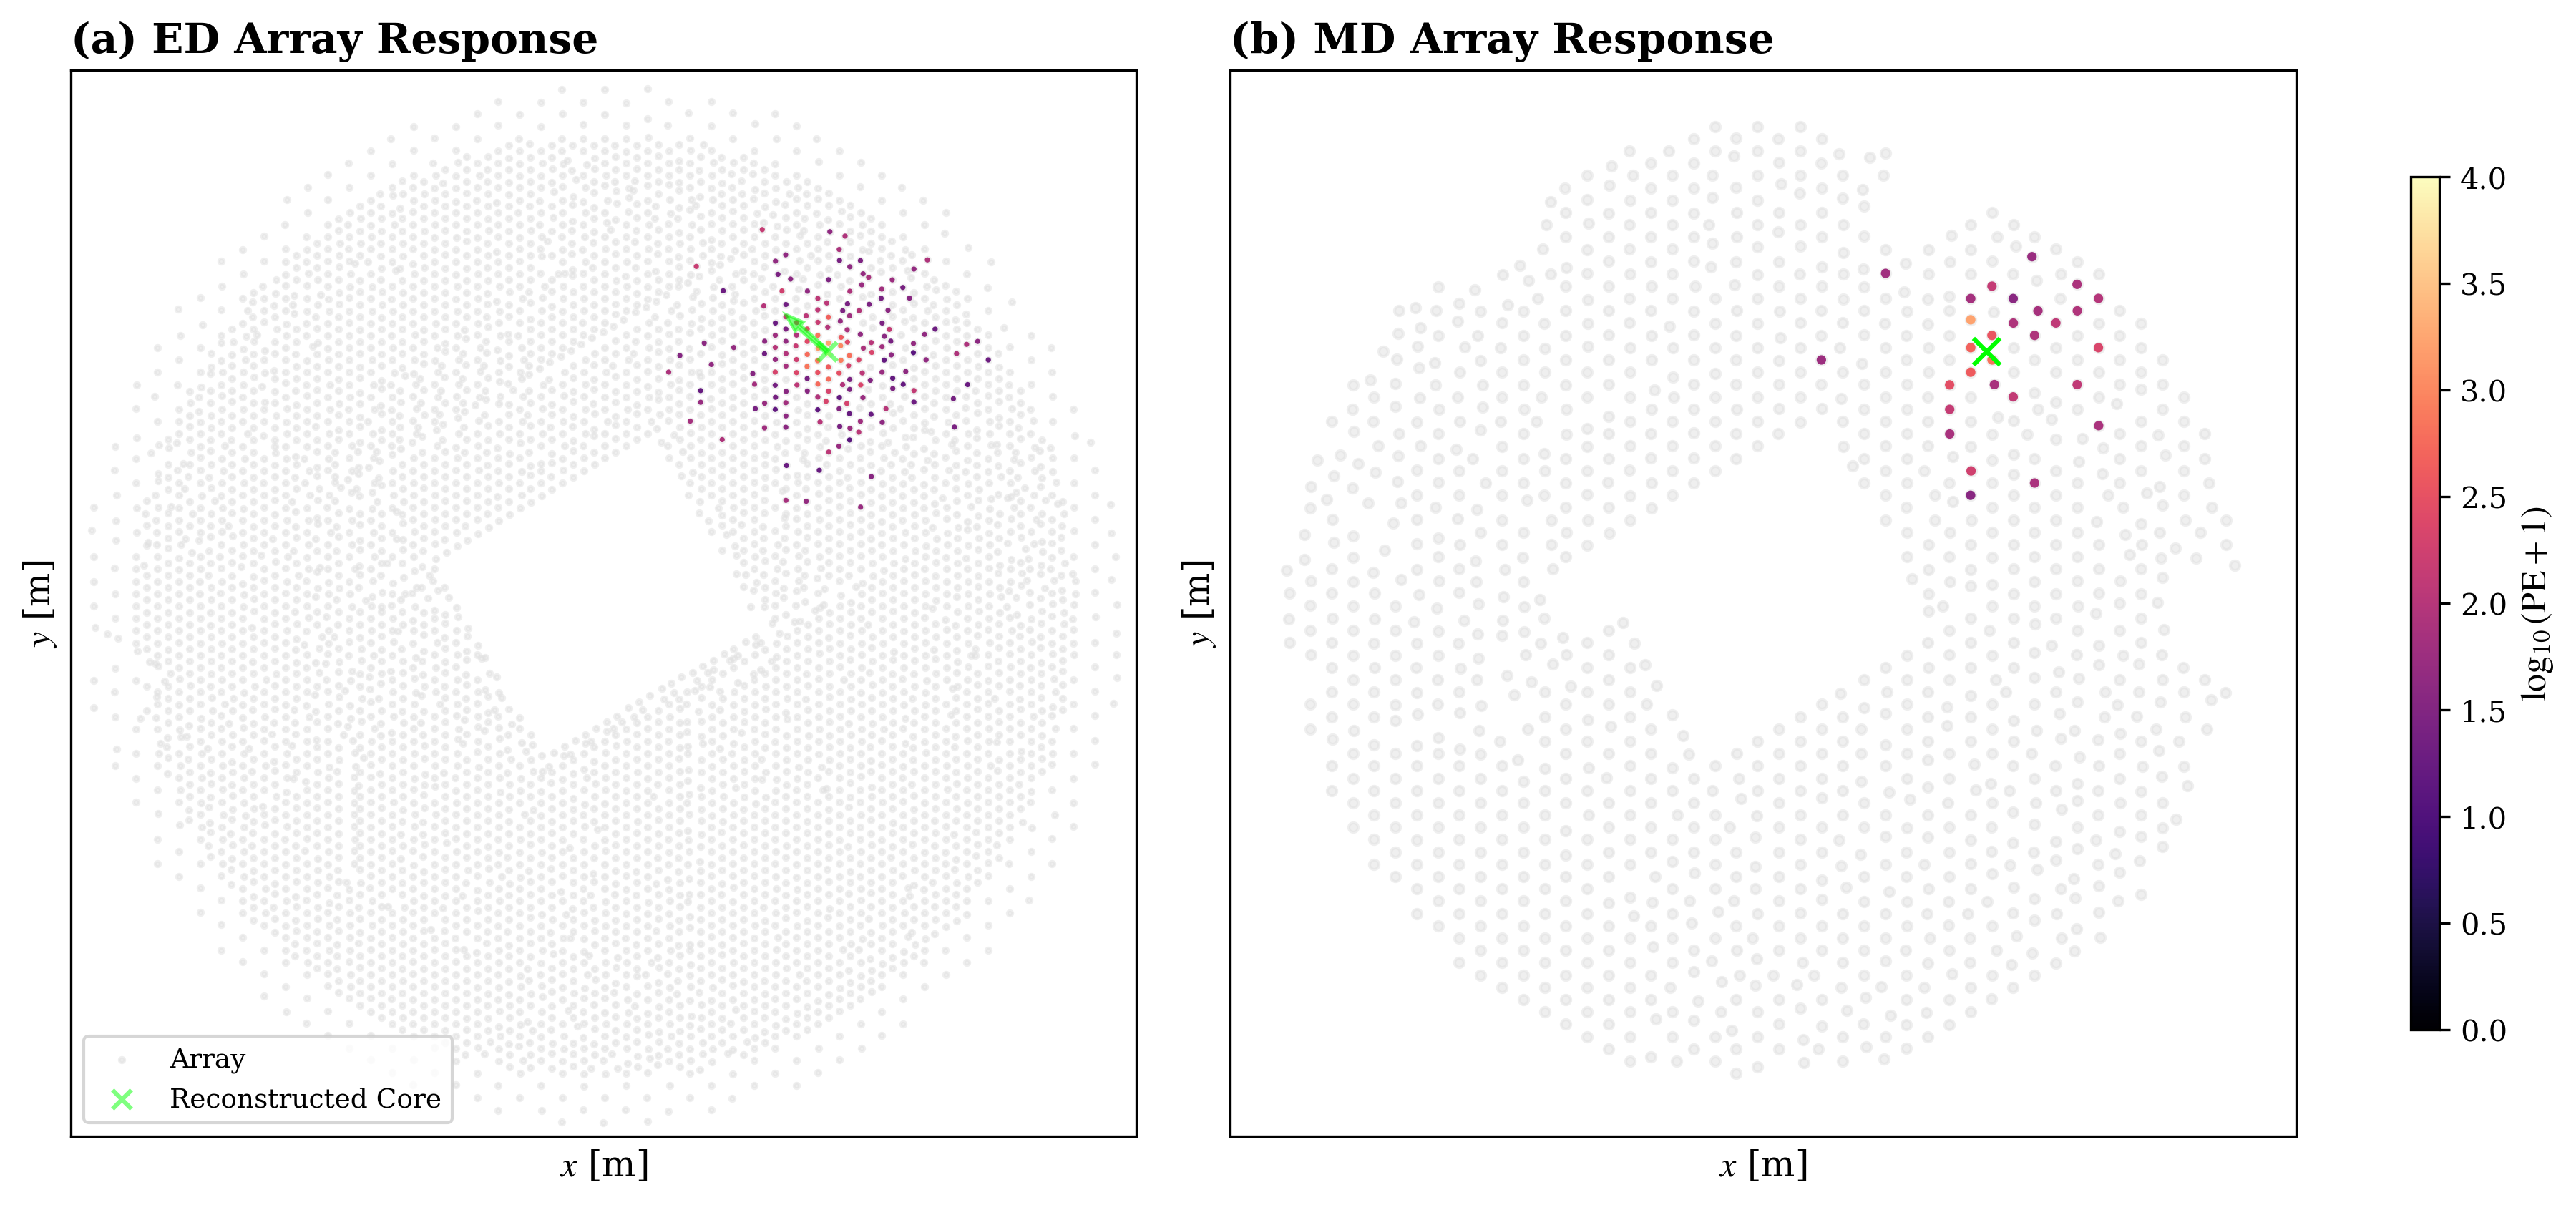

In [7]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os

def event_plot_npz(index, hitsE_all, hitsM_all, df_params, flag=7, figpath=None):
    
    
    # 配置学术字体
    plt.rcParams["font.family"] = "serif"
    plt.rcParams["mathtext.fontset"] = "stix"
    
        
        
    def load_pos(flag:int):
        ED_pos_file = None
        MD_pos_file = None
        script_dir = "/data/home/zzh/Filt_Event"
        if flag==7:
            ED_pos_file=f'{script_dir}/config/ED_pos_all.txt'
            MD_pos_file=f'{script_dir}/config/MD_pos_all.txt'
        else:
            MD_pos_file=f'{script_dir}/config/MD_pos_1188.txt'
            if 20191224 < flag < 20201201:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_half.txt'
            elif 20201130 < flag < 20210720:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_3978.txt'
            elif 20210719 < flag < 20210807:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5216up_20210720.txt'
            elif 20210806 < flag < 20220526:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5216up_20210807.txt'
            elif 20220525 < flag < 20220601:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5216up_20220520.txt'
            elif 20220531 < flag < 20220705:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5216up_20220601.txt'
            elif 20220704 < flag < 20221118:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5216up_20220705.txt'
            elif 20221117 < flag < 20230504:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5217up_20221118.txt'
            elif 20230503 < flag < 20230619:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5217up_20230504.txt'
            elif 20230618 < flag < 20230913:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5217up_20230619.txt'
            elif 20230912 < flag < 20231008:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5217up_20230913.txt'
            elif 20231007 < flag < 20241021:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5217up_20231008.txt'
            elif 20241020 < flag < 20250617:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5218up_20241021.txt'
            elif flag > 20250616:
                ED_pos_file = f'{script_dir}/config/Coordination/ED_pos_5218up_20250617.txt'
            else:
                # 增加一个容错处理，防止传入的 flag 刚好落在边界或非法范围外导致 ED_pos_file 未定义
                raise ValueError(f"输入的 flag ({flag}) 不在任何已知的坐标配置时间段内，请检查！")
        
        if ED_pos_file is not None:
            if os.path.exists(ED_pos_file) and os.path.exists(MD_pos_file):
                ED_pos=pd.read_csv(ED_pos_file,  sep=r'\s+',   skiprows=1,header=None, names=["id","x","y","z"])
                MD_pos=pd.read_csv(MD_pos_file,  sep=r'\s+',   skiprows=1,header=None, names=["id","x","y","z"])
                for col in ['x', 'y', 'z']:
                    ED_pos[col] = pd.to_numeric(ED_pos[col], errors='coerce')
                    MD_pos[col] = pd.to_numeric(MD_pos[col], errors='coerce')

                return ED_pos,MD_pos
        else:

            raise ValueError("wrong flag")
    
    
    
    # 1. 加载阵列位置
    ED_pos, MD_pos = load_pos(flag)

    # 2. 提取数据
    hE = hitsE_all[index]
    hM = hitsM_all[index]
    row = df_params.iloc[index]
    core = [row['rec_x'], row['rec_y']]
    theta, phi = row['rec_theta'], row['rec_phi']

    # 3. 计算指向箭头 (转换坐标系或方向)
    # 这里的 dx, dy 逻辑保持原样，但增加 arrow_width 的美化
    arrow_len = 220
    dx = -np.sin(theta) * np.sin(phi) * arrow_len
    dy = np.sin(theta) * np.cos(phi) * arrow_len

    # 4. 开始绘图
    # 使用 constrained_layout 替代 tight_layout，能更好地处理 colorbar 间距
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5.5), constrained_layout=True, dpi=300)
    
    # 公用的绘图参数
    scatter_kwargs = {
        'cmap': 'magma', # 更有科研质感的渐变色
        'vmin': 0, 
        'vmax': 4,       # 固定 log10(PE) 范围，方便左右对比
        'edgecolors': 'none'
    }

    # --- 左图：ED Hits ---
    ax1.scatter(ED_pos['x'], ED_pos['y'], c='#E0E0E0', s=3, alpha=0.5, label='Array', zorder=1)
    sc1 = ax1.scatter(hE[:, 0], hE[:, 1], c=np.log10(hE[:, 3] + 1), 
                      s=3, zorder=3, **scatter_kwargs)
    
    # 核心位置与箭头
    ax1.scatter(core[0], core[1], c='#00FF00', s=40, marker='x', label='Reconstructed Core', zorder=10, alpha=0.5)
    ax1.arrow(core[0], core[1], dx, dy, color='#00FF00', width=5, head_width=15, alpha=0.5 ,
              length_includes_head=True, zorder=11)
    
    ax1.set_title('(a) ED Array Response', fontsize=14, loc='left', fontweight='bold')

    # --- 右图：MD Hits ---
    ax2.scatter(MD_pos['x'], MD_pos['y'], c='#E0E0E0', s=10, alpha=0.5, zorder=1)
    sc2 = ax2.scatter(hM[:, 0], hM[:, 1], c=np.log10(hM[:, 3] + 1), 
                      s=10, zorder=3, **scatter_kwargs)
    
    ax2.scatter(core[0], core[1], c='#00FF00', s=80, marker='x', zorder=10)
    
    ax2.set_title('(b) MD Array Response', fontsize=14, loc='left', fontweight='bold')

    # 设置统一的 Colorbar
    cbar = fig.colorbar(sc2, ax=[ax1, ax2], location='right', aspect=30, shrink=0.8)
    cbar.set_label(r'$\log_{10}(\text{PE} + 1)$', fontsize=12)

    # 坐标轴细节优化
    for i, ax in enumerate([ax1, ax2]):
        ax.set_aspect('equal')
        ax.set_xlabel('$x$ [m]', fontsize=12)
        ax.set_ylabel('$y$ [m]', fontsize=12)
        ax.set_xlim(-650, 650)
        ax.set_ylim(-650, 650)
        ax.tick_params(direction='in', top=True, right=True)
        ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.3)
        if i == 0: ax.legend(loc='lower left', fontsize=9, framealpha=0.8)
    for ax in [ax1, ax2]:
        ax.set_xticks([]) # 取消 x 轴刻度和数字
        ax.set_yticks([])
    # 如果需要保存
    if figpath:
        plt.savefig(figpath, bbox_inches='tight', dpi=300)
    plt.show()

# 调用
# event_plot_npz_formal(0, hitsE, hitsM, mn_df, flag=7, figpath="event_display.pdf")
mn_file="/data/home/zzh/data/Dataset_Filted/Simulation/1e10_V04/Proton_combined_filted_1e10_V04_dataset_fastcode.npz"
mn_data = np.load(mn_file, allow_pickle=True)
hitsE = mn_data['hitsE']; hitsM = mn_data['hitsM']; mn_df = pd.DataFrame(mn_data['params'], columns=mn_data['param_names'][:32])


event_plot_npz(272307, hitsE, hitsM, mn_df, flag=20241020, figpath="/data/home/zzh/Filt_Event/Note_Writing/figures/1e10_Proton_display.pdf")




In [6]:
print(mn_df['trueE'][-20:])

272303     148730.21875
272304    227952.609375
272305    106150.070312
272306       387126.125
272307    182792.453125
272308     225073.96875
272309      350734.0625
272310    106150.070312
272311     225073.96875
272312     195005.71875
272313     281321.53125
272314    142249.078125
272315      350734.0625
272316     348438.15625
272317     117330.28125
272318       387126.125
272319    182792.453125
272320     225073.96875
272321     148730.21875
272322     195005.71875
Name: trueE, dtype: object
